In [3]:
import pandas as pd
data = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [4]:
#rename data -columns
data=data.rename(columns={'Review Text':'Reviews'})

In [5]:
#remove missing values
data=data.dropna()
data.reset_index(drop=True,inplace=True)
data.isna().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,0
Reviews,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0


In [6]:
# dropping extra columns
data = data.drop(["Clothing ID", "Division Name", "Department Name", "Class Name", "Title", "Age",
                  "Positive Feedback Count", "Recommended IND", "Unnamed: 0", ], axis=1)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19662 entries, 0 to 19661
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Reviews  19662 non-null  object
 1   Rating   19662 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 307.3+ KB


In [7]:
print(data)

                                                 Reviews  Rating
0      I had such high hopes for this dress and reall...       3
1      I love, love, love this jumpsuit. it's fun, fl...       5
2      This shirt is very flattering to all due to th...       5
3      I love tracy reese dresses, but this one is no...       2
4      I aded this in my basket at hte last mintue to...       5
...                                                  ...     ...
19657  I was very happy to snag this dress at such a ...       5
19658  It reminds me of maternity clothes. soft, stre...       3
19659  This fit well, but the top was very see throug...       3
19660  I bought this dress for a wedding i have this ...       3
19661  This dress in a lovely platinum is feminine an...       5

[19662 rows x 2 columns]


In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Tokenization and stopword removal function
def rem_stopwords_tokenize(data, name):
    def getting(sen):
        filtered_sentence = []
        stop_words = set(stopwords.words('english'))
        word_tokens = word_tokenize(sen)
        filtered_sentence = [w for w in word_tokens if not w in stop_words]
        return filtered_sentence

    x = []
    for i in data[name].values:
        x.append(getting(i))
    data[name] = x

# Lemmatization function
lemmatizer = WordNetLemmatizer()

def Lemmatization(data, name):
    def getting2(sen):
        output_sentence = []
        word_tokens2 = word_tokenize(sen)
        lemmatized_output = [lemmatizer.lemmatize(w) for w in word_tokens2]
        without_single_chr = [word for word in lemmatized_output if len(word) > 2]
        cleaned_data_title = [word for word in without_single_chr if not word.isnumeric()]
        return cleaned_data_title

    x = []
    for i in data[name].values:
        x.append(getting2(i))
    data[name] = x

# Convert tokenized data back to sentences
def make_sentences(data, name):
    data[name] = data[name].apply(lambda x: ' '.join([i for i in x]))
    data[name] = data[name].apply(lambda x: re.sub(r'\s+', ' ', x, flags=re.I))



In [11]:
import nltk
from nltk.corpus import wordnet as wn, sentiwordnet as swn
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Make sure you have downloaded the necessary NLTK data files
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('sentiwordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

pos=neg=obj=count=0

postagging = []

for review in data['Reviews']:
    list = word_tokenize(review)
    postagging.append(nltk.pos_tag(list))

data['pos_tags'] = postagging

def penn_to_wn(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    elif tag.startswith('V'):
        return wn.VERB
    return None

# Returns list of pos–neg and objective score. But returns empty list if not present in senti wordnet.
def get_sentiment(word, tag):
    wn_tag = penn_to_wn(tag)

    if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
        return []

    # Lemmatization
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)
    if not lemma:
        return []

    # SentiWordNet is a lexical resource for opinion mining. SentiWordNet assigns to each synset of WordNet three sentiment scores: positivity, negativity, and objectivity.
    # Synset is a special kind of a simple interface that is present in NLTK to look up words in WordNet.
    # Synset instances are the groupings of synonymous words that express the same concept.
    # Some of the words have only one Synset and some have several.
    synsets = wn.synsets(word, pos=wn_tag)
    if not synsets:
        return []

    # Take the first sense, the most common
    synset = synsets[0]
    swn_synset = swn.senti_synset(synset.name())

    return [synset.name(), swn_synset.pos_score(), swn_synset.neg_score(), swn_synset.obj_score()]

pos=neg=obj=count=0

###########################################################

senti_score = []

for pos_val in data['pos_tags']:
    senti_val = [get_sentiment(x,y) for (x,y) in pos_val]
    for score in senti_val:
        try:
            pos = pos + score[1] #positive score is stored at 2nd position
            neg = neg + score[2] #negative score is stored at 3rd position
        except:
            continue
    senti_score.append(pos - neg)
    pos=neg=0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [12]:
print(data)

                                                 Reviews  Rating  \
0      I had such high hopes for this dress and reall...       3   
1      I love, love, love this jumpsuit. it's fun, fl...       5   
2      This shirt is very flattering to all due to th...       5   
3      I love tracy reese dresses, but this one is no...       2   
4      I aded this in my basket at hte last mintue to...       5   
...                                                  ...     ...   
19657  I was very happy to snag this dress at such a ...       5   
19658  It reminds me of maternity clothes. soft, stre...       3   
19659  This fit well, but the top was very see throug...       3   
19660  I bought this dress for a wedding i have this ...       3   
19661  This dress in a lovely platinum is feminine an...       5   

                                                pos_tags  
0      [(I, PRP), (had, VBD), (such, JJ), (high, JJ),...  
1      [(I, PRP), (love, VBP), (,, ,), (love, VBP), (...  
2     

In [13]:
import pandas as pd



# List of columns to drop
columns_to_drop = ['pos_tags', 'senti_score']
data= pd.read_csv('Womens Clothing E-Commerce Reviews.csv')
# Drop columns that exist in the DataFrame
data= data.drop(columns=[col for col in columns_to_drop if col in data.columns])

# Convert ratings to sentiment
def convert_sentiment(rating):
    if rating <= 3:
        return 0  # Negative
    else:
        return 1  # Positive

# Apply the function to the 'Rating' column
data['Rating'] = data['Rating'].apply(convert_sentiment)

# Convert 'Rating' column to string
data['Rating'] = data['Rating'].astype(str)

# Print the updated DataFrame
print(data.head())



#rename data -columns
data=data.rename(columns={'Review Text':'Reviews'})

# dropping extra columns
data = data.drop(["Clothing ID", "Division Name", "Department Name", "Class Name", "Title", "Age",
                  "Positive Feedback Count", "Recommended IND", "Unnamed: 0", ], axis=1)

#remove missing values
data=data.dropna()
data.reset_index(drop=True,inplace=True)
data.isna().sum()

   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...      1                1   
1  Love this dress!  it's sooo pretty.  i happene...      1                1   
2  I had such high hopes for this dress and reall...      0                0   
3  I love, love, love this jumpsuit. it's fun, fl...      1                1   
4  This shirt is very flattering to all due to th...      1                1   

   Positive Feedback Count   Division Name Department Name Class Name  
0                        0       Initmates        Intimate  Intimates  
1             

,0
Reviews,0
Rating,0


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


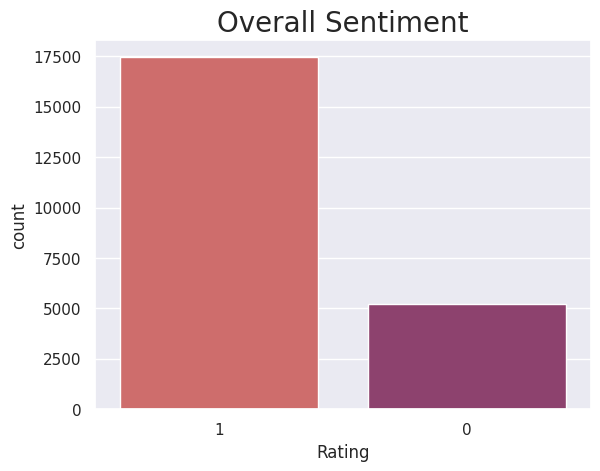

In [15]:
# imbalance-dataset
sns.set(style="darkgrid")
bar = sns.countplot(x='Rating', hue='Rating', data=data, palette="flare")
bar.set_title("Overall Sentiment", size=20)
plt.show()

In [16]:
print(data.columns)


Index(['Reviews', 'Rating'], dtype='object')


In [17]:
print(data)
X = data["Reviews"]
Y = data["Rating"]
data

                                                 Reviews Rating
0      Absolutely wonderful - silky and sexy and comf...      1
1      Love this dress!  it's sooo pretty.  i happene...      1
2      I had such high hopes for this dress and reall...      0
3      I love, love, love this jumpsuit. it's fun, fl...      1
4      This shirt is very flattering to all due to th...      1
...                                                  ...    ...
22636  I was very happy to snag this dress at such a ...      1
22637  It reminds me of maternity clothes. soft, stre...      0
22638  This fit well, but the top was very see throug...      0
22639  I bought this dress for a wedding i have this ...      0
22640  This dress in a lovely platinum is feminine an...      1

[22641 rows x 2 columns]


,Reviews,Rating
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1
...,...,...
22636,I was very happy to snag this dress at such a ...,1
22637,"It reminds me of maternity clothes. soft, stre...",0
22638,"This fit well, but the top was very see throug...",0
22639,I bought this dress for a wedding i have this ...,0


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import NearMiss
import numpy as np

tf = TfidfVectorizer(min_df=1, max_df=1.0, use_idf=True, ngram_range=(1, 2))
X = tf.fit_transform(X)

smk = SMOTETomek(random_state=42, sampling_strategy=0.8)
X_res, y_res = smk.fit_resample(X, Y)

unique_elements, counts_elements = np.unique(y_res, return_counts=True)
np.asarray((unique_elements, counts_elements))


array([['0', '1'],
       [13958, 17448]], dtype=object)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict the test set results
y_pred = logreg.predict(X_test)
# Print the confusion matrix



In [21]:
# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Logistic Regression):\n", cm)

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2824
           1       0.93      0.93      0.93      3458

    accuracy                           0.92      6282
   macro avg       0.92      0.92      0.92      6282
weighted avg       0.92      0.92      0.92      6282

Confusion Matrix (Logistic Regression):
 [[2576  248]
 [ 254 3204]]


In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict the test set results
y_pred = nb.predict(X_test)

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)
# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Naive Bayes):\n", cm)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2824
           1       0.91      0.95      0.93      3458

    accuracy                           0.92      6282
   macro avg       0.92      0.92      0.92      6282
weighted avg       0.92      0.92      0.92      6282

Confusion Matrix (Naive Bayes):
 [[2516  308]
 [ 188 3270]]


In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the SVM classifier
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

# Predict the test set results
y_pred = svm.predict(X_test)

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)

# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (SVM):\n", cm)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2824
           1       0.97      0.93      0.95      3458

    accuracy                           0.95      6282
   macro avg       0.94      0.95      0.95      6282
weighted avg       0.95      0.95      0.95      6282

Confusion Matrix (SVM):
 [[2712  112]
 [ 225 3233]]


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict the test set results
y_pred = dt.predict(X_test)

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)
# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Decision Tree):\n", cm)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      2824
           1       0.85      0.85      0.85      3458

    accuracy                           0.84      6282
   macro avg       0.83      0.83      0.83      6282
weighted avg       0.84      0.84      0.84      6282

Confusion Matrix (Decision Tree):
 [[2306  518]
 [ 517 2941]]


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize and train the Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict the test set results
y_pred = rf.predict(X_test)

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)
# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Random Forest):\n", cm)

              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2824
           1       0.89      0.97      0.93      3458

    accuracy                           0.92      6282
   macro avg       0.92      0.91      0.92      6282
weighted avg       0.92      0.92      0.92      6282

Confusion Matrix (Random Forest):
 [[2413  411]
 [ 107 3351]]


In [26]:
import joblib

joblib.dump(rf, "sentiment_model.pkl")
joblib.dump(tf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')